<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/100k_Test/VanillaBCNN_Optimized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Uncomment this line if Pyro is not installed.
%pip install pyro-ppl torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 14.7 MB/s eta 0:00:00


In [6]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/REU ECG Analysis
!ls

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1R0Rm_tQkPv4BMW6L3PT9j80xpPsVEffJ/REU ECG Analysis
 BCNN		        EchonextBigData
 CNN		        EchoNext_EchoData_5K.csv
'CNN Models ALL.gdoc'  'Project Summary.gdoc'
 ECG_metrics_1K.npy    'TripleCNN Model Overview (Pooling Methods).gdoc'
 ECG_waveforms_1K.npy


Using device: cuda

Split sizes -> train: 720, val: 180, test: 100
Beginning execution pipeline...
Training model...

===== Individual Test Sample Inference Profiles ====
Sample 000 | True: 1 | Pred: 1 | Confidence: 0.9004 | Uncertainty (Std): 0.1879
Sample 001 | True: 1 | Pred: 1 | Confidence: 0.9849 | Uncertainty (Std): 0.0937
Sample 002 | True: 1 | Pred: 1 | Confidence: 0.8317 | Uncertainty (Std): 0.2603
Sample 003 | True: 0 | Pred: 0 | Confidence: 0.5303 | Uncertainty (Std): 0.2917
Sample 004 | True: 1 | Pred: 1 | Confidence: 0.8464 | Uncertainty (Std): 0.2082
Sample 005 | True: 1 | Pred: 1 | Confidence: 0.7733 | Uncertainty (Std): 0.2099
Sample 006 | True: 0 | Pred: 0 | Confidence: 0.8430 | Uncertainty (Std): 0.2791
Sample 007 | True: 0 | Pred: 0 | Confidence: 0.6526 | Uncertainty (Std): 0.2006
Sample 008 | True: 0 | Pred: 1 | Confidence: 0.5367 | Uncertainty (Std): 0.2371
Sample 009 | True: 0 | Pred: 0 | Confidence: 0.7347 | Uncertainty (Std): 0.1746
Sample 010 | True: 0 | Pred: 

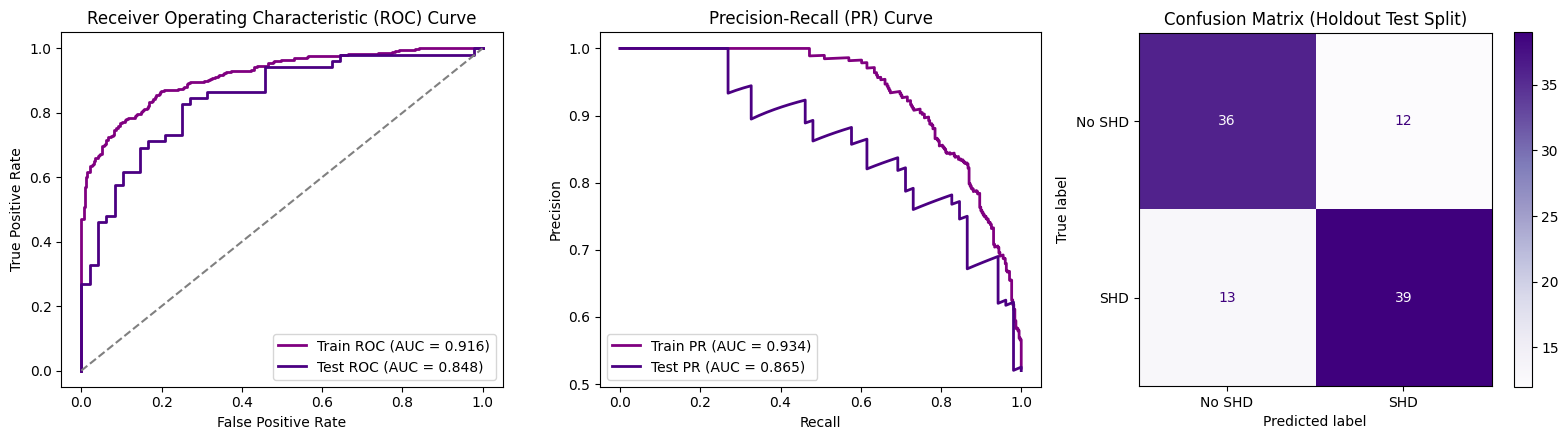

In [7]:
"""
BayesianSmallCNN: 12-lead ECG Bayesian Multi-modal/Time-Series Classifier
for structural heart disease (shd_moderate_or_greater_flag) using Pyro SVI.

Pipeline (in order):
  1. Load raw ECG waveforms and demographic outcome label data.
  2. Split into train / val / test = 72% / 18% / 10% stratified layout
     to avoid data leakage.
  3. Build PyTorch DataLoaders and train the Bayesian CNN via Variational Inference.
  4. Evaluate on train and on the held-out test set: per-sample predictions,
     confidence metrics, and full side-by-side analytical profiles.
"""

import math
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.nn import PyroModule, PyroSample
from pyro.optim import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc,
    roc_curve,
    brier_score_loss,
    ConfusionMatrixDisplay
)

# ──────────────────────────────────────────────────────────────────────
# 0. CONFIGURATION & HYPERPARAMETERS
# ──────────────────────────────────────────────────────────────────────
RANDOM_SEED = 42
def set_seed(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)
pyro.set_rng_seed(RANDOM_SEED)
pyro.clear_param_store()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

N_SAMPLES = 1000

# ──────────────────────────────────────────────────────────────────────
# 1. DATA INGESTION & TENSOR CONVERSION
# ──────────────────────────────────────────────────────────────────────
ECG_data_1K = np.load('ECG_waveforms_1K.npy')
Echo_5K = pd.read_csv('EchoNext_EchoData_5K.csv')

labels = Echo_5K['shd_moderate_or_greater_flag']
y_ts = np.array(labels[:N_SAMPLES])
X = ECG_data_1K[:N_SAMPLES]
X_ts = np.swapaxes(X, 1, 2)  # Shape: [N, 12, L]

# ──────────────────────────────────────────────────────────────────────
# 2. DATASET PARTITIONING (72% Train / 18% Val / 10% Test)
# ──────────────────────────────────────────────────────────────────────
all_idx = np.arange(N_SAMPLES)
trainval_idx, test_idx = train_test_split(
    all_idx, test_size=0.10, random_state=RANDOM_SEED, stratify=y_ts
)
train_idx, val_idx = train_test_split(
    trainval_idx, test_size=0.20, random_state=RANDOM_SEED, stratify=y_ts[trainval_idx]
)

print(f"\nSplit sizes -> train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}")

def make_loader(idx, batch_size, shuffle):
    X_t = torch.tensor(X_ts[idx], dtype=torch.float32)
    y_t = torch.tensor(y_ts[idx], dtype=torch.long)
    dataset = TensorDataset(X_t, y_t)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

ts_train_loader = make_loader(train_idx, batch_size=32, shuffle=False) # Keep fixed order for structured profiles
ts_val_loader = make_loader(val_idx, batch_size=128, shuffle=False)
ts_test_loader = make_loader(test_idx, batch_size=128, shuffle=False)

# ──────────────────────────────────────────────────────────────────────
# 3. BAYESIAN SMALL CNN ARCHITECTURE
# ──────────────────────────────────────────────────────────────────────
class BayesianSmallCNN(PyroModule):
    def __init__(self, prior_scale=2.0, pooled_len=1):
        super().__init__()
        self.pooled_len = pooled_len
        self.prior_scale = prior_scale
        self.register_buffer("_device_anchor", torch.tensor(0.0))

        def make_prior(shape):
            def prior(_module):
                dev = self._device_anchor.device
                loc = torch.tensor(0.0, device=dev)
                scale = torch.tensor(prior_scale, device=dev)
                return dist.Normal(loc, scale).expand(shape).to_event(len(shape))
            return prior

        conv1_out, conv1_k, conv1_pad = 50, 51, 1
        hidden_out, hidden_k, hidden_pad = 31, 21, 1

        def make_bayesian_conv(in_ch, out_ch, kernel_size, padding):
            layer = PyroModule[nn.Conv1d](in_ch, out_ch, kernel_size=kernel_size, padding=padding)
            layer.weight = PyroSample(make_prior([out_ch, in_ch, kernel_size]))
            layer.bias = PyroSample(make_prior([out_ch]))
            return layer

        self.conv1 = make_bayesian_conv(12, conv1_out, conv1_k, conv1_pad)
        self.conv2 = make_bayesian_conv(conv1_out, hidden_out, hidden_k, hidden_pad)
        self.conv3 = make_bayesian_conv(hidden_out, hidden_out, hidden_k, hidden_pad)
        self.conv4 = make_bayesian_conv(hidden_out, hidden_out, hidden_k, hidden_pad)

        self.bn1 = nn.BatchNorm1d(conv1_out)
        self.bn2 = nn.BatchNorm1d(hidden_out)
        self.bn3 = nn.BatchNorm1d(hidden_out)
        self.bn4 = nn.BatchNorm1d(hidden_out)

        self.fc1 = PyroModule[nn.Linear](hidden_out, 32)
        self.fc1.weight = PyroSample(make_prior([32, hidden_out]))
        self.fc1.bias = PyroSample(make_prior([32]))

        self.fc2 = PyroModule[nn.Linear](32, 2)
        self.fc2.weight = PyroSample(make_prior([2, 32]))
        self.fc2.bias = PyroSample(make_prior([2]))

    def forward(self, x, y=None, dataset_size=None):
        x = x.to(self._device_anchor.device)
        if y is not None:
            y = y.to(self._device_anchor.device)

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool1d(x, kernel_size=2)
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool1d(x, kernel_size=2)
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.max_pool1d(x, kernel_size=2)
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.max_pool1d(x, kernel_size=2)

        x = F.adaptive_avg_pool1d(x, 1)
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        logits = self.fc2(x)

        if y is not None and dataset_size is not None:
            scale = dataset_size / x.shape[0]
        else:
            scale = 1.0

        with pyro.plate("data", x.shape[0]):
            with pyro.poutine.scale(scale=scale):
                pyro.sample("obs", dist.Categorical(logits=logits), obs=y)

        return logits

# ──────────────────────────────────────────────────────────────────────
# 4. TRAINING PIPELINE (SVI LOOP)
# ──────────────────────────────────────────────────────────────────────
bcnn = BayesianSmallCNN(prior_scale=2.0).to(device)
bcnn_guide = AutoDiagonalNormal(bcnn)
bcnn_optimizer = Adam({"lr": 1e-3, "betas": (0.9, 0.999)})
bcnn_svi = SVI(model=bcnn, guide=bcnn_guide, optim=bcnn_optimizer, loss=Trace_ELBO())

def train_one_epoch_svi(svi, data_loader, device, dataset_size):
    model.train()
    total_loss = 0.0
    total_examples = 0
    for x, y in data_loader:
        x, y = x.to(device), y.to(device)
        loss = svi.step(x, y, dataset_size)
        total_loss += loss
        total_examples += x.shape[0]
    return total_loss / max(1, total_examples)

# ──────────────────────────────────────────────────────────────────────
# 5. PERFORMANCE METRICS GENERATION & CALIBRATION ESTIMATION
# ──────────────────────────────────────────────────────────────────────
def calculate_calibration_error(probs, labels, bins=10):
    bin_boundaries = np.linspace(0, 1, bins + 1)
    ece = 0.0
    for i in range(bins):
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i + 1]
        in_bin = (probs >= bin_lower) & (probs < bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(labels[in_bin] == (probs[in_bin] >= 0.5))
            avg_confidence_in_bin = np.mean(probs[in_bin])
            ece += prop_in_bin * np.abs(avg_confidence_in_bin - accuracy_in_bin)
    return ece

@torch.no_grad()
def get_predictions_and_labels_bayesian(model, guide, loader, num_samples=100):
    model.eval()
    all_probs, all_labels = [], []

    # Calculate approximate NLL over the full dataset using Pyro's custom loss function
    elbo = Trace_ELBO()
    total_nll = 0.0
    total_examples = 0

    for x, y in loader:
        x_dev, y_dev = x.to(device), y.to(device)

        # Bayesian probability estimation via posterior sampling
        predictive = Predictive(model, guide=guide, num_samples=num_samples, return_sites=("_RETURN",))
        out = predictive(x_dev, None)
        logits_samples = out["_RETURN"]
        probs_samples = torch.softmax(logits_samples, dim=-1)
        mean_probs = probs_samples.mean(dim=0)

        loss = elbo.differentiable_loss(model, guide, x_dev, y_dev, x_dev.shape[0])
        total_nll += float(loss.detach().cpu())
        total_examples += x_dev.shape[0]

        all_probs.extend(mean_probs[:, 1].cpu().numpy())
        all_labels.extend(y.numpy())

    return np.array(all_probs), np.array(all_labels), total_nll / max(total_examples, 1)

def generate_and_display_comparative_metrics(model, guide, train_loader, test_loader, num_samples=100):
    """ Computes summary metrics for train vs. test, prints the structured side-by-side
    comparison table, and renders integrated metric evaluation profiles.
    """
    train_probs, train_labels, train_nll = get_predictions_and_labels_bayesian(model, guide, train_loader, num_samples)
    test_probs, test_labels, test_nll = get_predictions_and_labels_bayesian(model, guide, test_loader, num_samples)

    train_preds = (train_probs >= 0.5).astype(int)
    test_preds = (test_probs >= 0.5).astype(int)

    metrics_map = {
        "accuracy": (np.mean(train_preds == train_labels), np.mean(test_preds == test_labels)),
        "auroc": (roc_auc_score(train_labels, train_probs), roc_auc_score(test_labels, test_probs)),
        "auprc": (None, None),
        "brier_score": (brier_score_loss(train_labels, train_probs), brier_score_loss(test_labels, test_probs)),
        "negative_log_likelihood": (train_nll, test_nll),
        "expected_calibration_error": (calculate_calibration_error(train_probs, train_labels), calculate_calibration_error(test_probs, test_labels))
    }

    train_precision, train_recall, _ = precision_recall_curve(train_labels, train_probs)
    train_fpr, train_tpr, _ = roc_curve(train_labels, train_probs)
    metrics_map["auprc"] = (auc(train_recall, train_precision), metrics_map["auprc"][1])

    test_precision, test_recall, _ = precision_recall_curve(test_labels, test_probs)
    test_fpr, test_tpr, _ = roc_curve(test_labels, test_probs)
    metrics_map["auprc"] = (metrics_map["auprc"][0], auc(test_recall, test_precision))

    tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(train_labels, train_preds).ravel()
    tn_te, fp_te, fn_te, tp_te = confusion_matrix(test_labels, test_preds).ravel()

    metrics_map["tn"] = (float(tn_tr), float(tn_te))
    metrics_map["fp"] = (float(fp_tr), float(fp_te))
    metrics_map["fn"] = (float(fn_tr), float(fn_te))
    metrics_map["tp"] = (float(tp_tr), float(tp_te))

    # ── PRINT EXACT ALIGNED TEXT TABLE ──
    print("\nClassification metrics (train vs. test):")
    print(f"{'':<28} {'train':<10} {'test':<10}")
    for k, v in metrics_map.items():
        print(f"{k:<28} {v[0]:.6f}   {v[1]:.6f}")

    # ── PLOT ANALYSIS GRAPH PROFILES ──
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

    # 1. ROC Curves
    ax[0].plot(train_fpr, train_tpr, color='purple', lw=2, label=f'Train ROC (AUC = {metrics_map["auroc"][0]:.3f})')
    ax[0].plot(test_fpr, test_tpr, color='indigo', lw=2, label=f'Test ROC (AUC = {metrics_map["auroc"][1]:.3f})')
    ax[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].set_title('Receiver Operating Characteristic (ROC) Curve')
    ax[0].legend(loc='lower right')

    # 2. Precision-Recall Curves
    ax[1].plot(train_recall, train_precision, color='purple', lw=2, label=f'Train PR (AUC = {metrics_map["auprc"][0]:.3f})')
    ax[1].plot(test_recall, test_precision, color='indigo', lw=2, label=f'Test PR (AUC = {metrics_map["auprc"][1]:.3f})')
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].set_title('Precision-Recall (PR) Curve')
    ax[1].legend(loc='lower left')

    # 3. Consolidated Confusion Matrix (Test Split)
    cm_test = confusion_matrix(test_labels, test_preds)
    ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["No SHD", "SHD"]).plot(ax=ax[2], cmap="Purples", values_format="d")
    ax[2].set_title("Confusion Matrix (Holdout Test Split)")

    plt.tight_layout()
    plt.show()

# ──────────────────────────────────────────────────────────────────────
# 6. EXECUTION PIPELINE
# ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Beginning execution pipeline...")

    num_epochs = 20
    print("Training model...")
    model = bcnn  # Map model context to the requested training variables

    for epoch in range(num_epochs):
        avg_loss = train_one_epoch_svi(
            bcnn_svi,
            ts_train_loader,
            device,
            dataset_size=len(train_idx)
        )

    # ── PRINT SAMPLE INDIVIDUAL INFERENCE RECORDS ─────────────
    print("\n===== Individual Test Sample Inference Profiles ====")
    bcnn.eval()
    sample_counter = 0

    with torch.no_grad():
        for x, y in ts_test_loader:
            x_dev = x.to(device)
            predictive = Predictive(bcnn, guide=bcnn_guide, num_samples=40, return_sites=("_RETURN",))
            out = predictive(x_dev, None)
            logits_samples = out["_RETURN"]
            probs_samples = torch.softmax(logits_samples, dim=-1)
            mean_probs = probs_samples.mean(dim=0).cpu().numpy()
            std_probs = probs_samples.std(dim=0).cpu().numpy()

            for idx in range(x.size(0)):
                true_val = y[idx].item()
                pred_val = np.argmax(mean_probs[idx])
                confidence = mean_probs[idx][pred_val]
                uncertainty = std_probs[idx][pred_val]

                print(f"Sample {sample_counter:03d} | True: {true_val} | Pred: {pred_val} | "
                      f"Confidence: {confidence:.4f} | Uncertainty (Std): {uncertainty:.4f}")
                sample_counter += 1

    # ── SYSTEM METRICS ANALYSIS VISUALIZATIONS ────────────────
    generate_and_display_comparative_metrics(bcnn, bcnn_guide, ts_train_loader, ts_test_loader, num_samples=100)